# Annotation & Tile-level Tumor Visualization

Based on Camelyon16 annotation XML tumor regions, visualize at the 20x tile-grid level:
1. **WSI Thumbnail + Tumor Contours**
2. **Tile-Grid Level**: adaptively crop each tumor region and label tumor/normal tiles
3. **Embedding Dimensionality Reduction**: t-SNE/UMAP colored by tumor vs normal

Tunable parameters:
- `SLIDE_ID`: WSI name (e.g., `"tumor_001"`)
- `TUMOR_THRESH`: area-ratio threshold for labeling a tile as tumor (default 0.20)
- `CONTEXT_PAD`: number of extra tile rows/cols expanded around tumor regions in grid visualization (default 10)
- `EMBEDDING_KEY`: embedding version to use (`"embeddings_20x_s"` or `"embeddings_20x_i"`)

In [ ]:
import numpy as np
import h5py
import openslide
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pathlib import Path
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, box
from shapely.ops import unary_union

print(f"openslide : {openslide.__version__}")

# Enable Chinese font support in matplotlib
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

openslide : 1.4.1


In [ ]:
# --- Tunable Parameters ------------------------------------------------------
SLIDE_ID      = "tumor_014"
TUMOR_THRESH  = 0.10     # tile tumor area ratio >= this threshold -> tumor tile
CONTEXT_PAD   = 10       # extra tile rows/cols shown around tumor regions
EMBEDDING_KEY = "embeddings_20x_i"   # "embeddings_20x_s" or "embeddings_20x_i"
CLUSTER_GAP   = 30       # distance threshold (in tile count) to separate tumor regions

# --- Paths ------------------------------------------------------------------
SLIDE_DIR  = Path("data/camelyon16/training/tumor")
ANNOT_DIR  = Path("data/camelyon16/annotations")
H5_DIR     = Path("tile_database")

slide_path = SLIDE_DIR / f"{SLIDE_ID}.tif"
xml_path   = ANNOT_DIR / f"{SLIDE_ID}.xml"
h5_path    = H5_DIR    / f"{SLIDE_ID}.h5"

for p, label in [(slide_path, "slide"), (xml_path, "annotation"), (h5_path, "h5")]:
    assert p.exists(), f"{label} not found: {p}"
    print(f"  {label:10s} : {p}")

  slide      : data\camelyon16\training\tumor\tumor_014.tif
  annotation : data\camelyon16\annotations\tumor_014.xml
  h5         : tile_database\tumor_014.h5


## Core Functions

- `parse_annotations_xml`: parse ASAP-format XML and return a list of Shapely polygons (level-0 coordinates)
- `compute_tile_tumor_labels`: compute tile-wise area overlap ratio with tumor polygons
- `cluster_tumor_regions`: cluster adjacent tumor tiles into independent visualization regions

In [ ]:
def parse_annotations_xml(xml_path):
    """
    Parse ASAP-format annotation XML and return a list of Shapely polygons.
    Coordinates are absolute level-0 pixel coordinates.
    Always returns Polygon objects (MultiPolygon is split into individual polygons).
    """
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    polygons = []
    for ann in root.iter('Annotation'):
        coords_elems = ann.findall('Coordinates/Coordinate')
        if len(coords_elems) < 3:
            continue
        pts = [(float(c.attrib['X']), float(c.attrib['Y'])) for c in coords_elems]
        poly = Polygon(pts)
        if poly.is_valid and not poly.is_empty:
            polygons.append(poly)
        else:
            # Try to repair invalid polygons (buffer(0) may create MultiPolygon)
            poly = poly.buffer(0)
            if not poly.is_empty:
                if poly.geom_type == 'MultiPolygon':
                    polygons.extend([g for g in poly.geoms if not g.is_empty])
                else:
                    polygons.append(poly)
    return polygons


def compute_tile_tumor_labels(coords, tile_size_l0, tumor_polygons):
    """
    For each tile, compute the intersection area ratio with tumor polygons.
    Use bbox pre-filtering and perform exact intersection only for possible overlaps.

    Args:
        coords: (N, 2) int32, level-0 (x, y)
        tile_size_l0: tile coverage size in level-0 pixels
        tumor_polygons: list of Shapely Polygon
    Returns:
        tumor_ratios: (N,) float32, tumor area ratio for each tile
    """
    tumor_union = unary_union(tumor_polygons)
    N = len(coords)
    tumor_ratios = np.zeros(N, dtype=np.float32)
    tile_area = float(tile_size_l0 * tile_size_l0)

    # Pre-filter: only evaluate tiles that may intersect the tumor bounding box
    tb = tumor_union.bounds  # (minx, miny, maxx, maxy)

    # Vectorized candidate tile filtering
    xs = coords[:, 0].astype(np.float64)
    ys = coords[:, 1].astype(np.float64)
    candidate_mask = (
        (xs + tile_size_l0 >= tb[0]) & (xs <= tb[2]) &
        (ys + tile_size_l0 >= tb[1]) & (ys <= tb[3])
    )
    candidate_idx = np.where(candidate_mask)[0]
    print(f"    bbox pre-filter: {len(candidate_idx)}/{N} candidates")

    for count, i in enumerate(candidate_idx):
        x, y = int(coords[i, 0]), int(coords[i, 1])
        tile_box = box(x, y, x + tile_size_l0, y + tile_size_l0)
        inter = tumor_union.intersection(tile_box)
        if not inter.is_empty:
            tumor_ratios[i] = inter.area / tile_area
        if (count + 1) % 500 == 0:
            print(f"    [{count+1}/{len(candidate_idx)}]")

    return tumor_ratios


def cluster_tumor_regions(tumor_mask_grid, context_pad, cluster_gap):
    """
    Cluster tumor tiles in a 2D tile grid into independent regions
    (based on connected components + distance),
    and return a list of (row_slice, col_slice) for each region.

    Args:
        tumor_mask_grid: (n_rows, n_cols) bool
        context_pad: extra context padding (tile count)
        cluster_gap: clustering distance threshold
    """
    n_rows, n_cols = tumor_mask_grid.shape

    # Connected-component analysis (dilate to merge nearby regions)
    kernel = np.ones((cluster_gap, cluster_gap), np.uint8)
    dilated = cv2.dilate(tumor_mask_grid.astype(np.uint8), kernel, iterations=1)
    n_labels, labels = cv2.connectedComponents(dilated)

    regions = []
    for label_id in range(1, n_labels):
        # Get precise boundaries from the original tumor mask
        mask_in_cluster = tumor_mask_grid & (labels == label_id)
        if not mask_in_cluster.any():
            continue
        t_ys, t_xs = np.where(mask_in_cluster)
        r_min = max(0, t_ys.min() - context_pad)
        r_max = min(n_rows, t_ys.max() + context_pad + 1)
        c_min = max(0, t_xs.min() - context_pad)
        c_max = min(n_cols, t_xs.max() + context_pad + 1)
        regions.append((slice(r_min, r_max), slice(c_min, c_max)))

    return regions


print("Core functions defined.")

Core functions defined.


## Load Data

Read tile coordinates, tissue mask, and embeddings from HDF5, then parse annotation XML.

In [ ]:
# --- 1. Read HDF5 ------------------------------------------------------------
with h5py.File(h5_path, 'r') as f:
    coords      = f['coords'][:]            # (N, 2) int32, level-0 (x, y)
    tissue_mask = f['tissue_mask'][:]        # (N,) bool
    thumbnail   = f['thumbnail'][:]          # (H, W, 3) uint8
    embeddings  = f[EMBEDDING_KEY][:]        # (N, D) float32
    tile_size   = int(f.attrs['tile_size'])  # 224
    level_20x   = int(f.attrs['level_20x'])
    slide_dims  = tuple(f.attrs['slide_dimensions'])  # (W, H) at level-0

N = len(coords)
print(f"Loaded {h5_path.name}:")
print(f"  N={N}, tile_size={tile_size}, level_20x={level_20x}")
print(f"  slide dims: {slide_dims}")
print(f"  tissue tiles: {tissue_mask.sum()}/{N}")
print(f"  embedding: {EMBEDDING_KEY} {embeddings.shape}")

# --- 2. Parse annotation XML -------------------------------------------------
tumor_polygons = parse_annotations_xml(xml_path)
print(f"  annotation polygons: {len(tumor_polygons)}")
for i, poly in enumerate(tumor_polygons):
    b = poly.bounds
    print(f"    [{i}] bbox x=[{b[0]:.0f}, {b[2]:.0f}], y=[{b[1]:.0f}, {b[3]:.0f}], "
          f"area={poly.area:.0f}")

# --- 3. Compute tile-level tumor area ratio ----------------------------------
# Tile coverage size in level-0: inferred from neighboring tile coordinate spacing
xs_unique = np.sort(np.unique(coords[:, 0]))
tile_size_l0 = int(xs_unique[1] - xs_unique[0]) if len(xs_unique) > 1 else tile_size
print(f"  tile_size at level-0: {tile_size_l0} px")

print("Computing tile-level tumor ratios ...")
tumor_ratios = compute_tile_tumor_labels(coords, tile_size_l0, tumor_polygons)
tumor_labels = tumor_ratios >= TUMOR_THRESH   # (N,) bool
n_tumor = int(tumor_labels.sum())
print(f"  tumor tiles (thresh>={TUMOR_THRESH:.0%}): {n_tumor}/{N}")

# --- 4. Grid shape ------------------------------------------------------------
n_cols = len(xs_unique)
ys_unique = np.sort(np.unique(coords[:, 1]))
n_rows = len(ys_unique)
print(f"  grid: {n_cols} cols x {n_rows} rows")

Loaded tumor_014.h5:
  N=103986, tile_size=224, level_20x=1
  slide dims: (np.int64(97792), np.int64(214016))
  tissue tiles: 23720/103986
  embedding: embeddings_20x_i (103986, 512)
  annotation polygons: 13
    [0] bbox x=[23849, 29417], y=[66274, 69571], area=10439250
    [1] bbox x=[27704, 27938], y=[68190, 68453], area=44803
    [2] bbox x=[27851, 30193], y=[65023, 67116], area=2110031
    [3] bbox x=[38039, 48776], y=[68094, 77234], area=56895189
    [4] bbox x=[41947, 42124], y=[76998, 77151], area=14043
    [5] bbox x=[42252, 42504], y=[76698, 76919], area=41023
    [6] bbox x=[47751, 48072], y=[72831, 73446], area=87739
    [7] bbox x=[43742, 44310], y=[73401, 74079], area=260645
    [8] bbox x=[43696, 44788], y=[69634, 70318], area=428706
    [9] bbox x=[43830, 44385], y=[70255, 70660], area=112262
    [10] bbox x=[44886, 45349], y=[72816, 73332], area=122439
    [11] bbox x=[44822, 45588], y=[72290, 72653], area=87358
    [12] bbox x=[47254, 47876], y=[71296, 71727], area=18

## Figure 1: WSI Thumbnail + Tumor Region Contours

Draw annotation polygon boundaries on the low-resolution thumbnail.

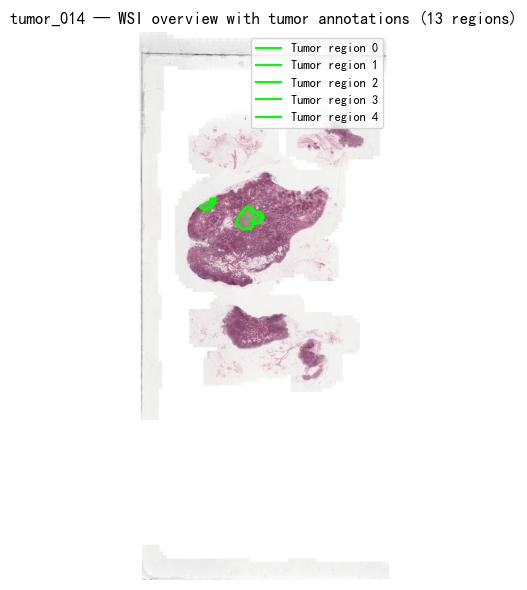

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.imshow(thumbnail)

thumb_h, thumb_w = thumbnail.shape[:2]
scale_x = thumb_w / slide_dims[0]
scale_y = thumb_h / slide_dims[1]

for i, poly in enumerate(tumor_polygons):
    # Polygon exterior boundary coordinates
    exterior = np.array(poly.exterior.coords)
    xs_scaled = exterior[:, 0] * scale_x
    ys_scaled = exterior[:, 1] * scale_y
    ax.plot(xs_scaled, ys_scaled, color='lime', linewidth=1.5,
            label=f'Tumor region {i}' if i < 5 else None)
    ax.fill(xs_scaled, ys_scaled, color='lime', alpha=0.15)

ax.legend(fontsize=9, loc='upper right')
ax.set_title(f"{SLIDE_ID} — WSI overview with tumor annotations "
             f"({len(tumor_polygons)} regions)", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## Figure 2: Tumor Region Visualization at Tile-Grid Level

Reshape `tumor_labels` into a 2D grid, cluster independent tumor regions, and display each region with adaptive cropping.
Green = tumor tile, gray = normal tile, black = non-tissue.

Found 1 tumor cluster(s)


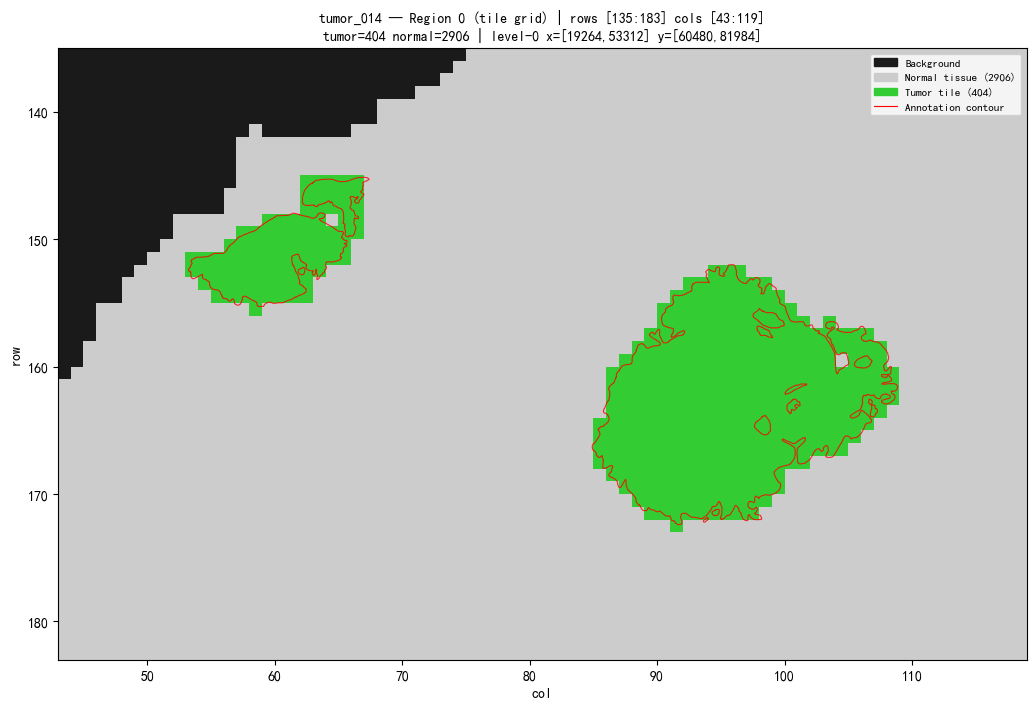

  Region 0: reading 48x76 tiles from 20x level ...


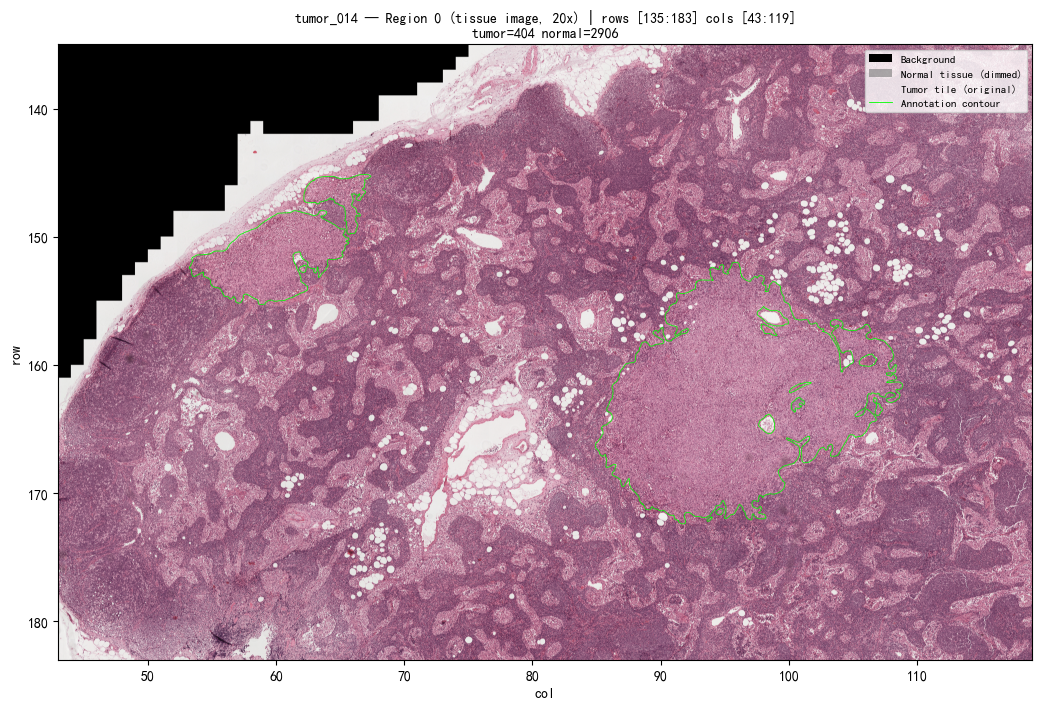

In [ ]:
def plot_tile_grid_regions(tumor_labels, tissue_mask, n_rows, n_cols,
                           tumor_polygons, coords, tile_size_l0,
                           context_pad, cluster_gap, slide_id,
                           slide_path, level_20x, tile_size):
    """Visualize tumor regions on the tile grid with adaptive per-region cropping.
    For each region, output a paired plot:
    left = color block grid, right = real tissue image + overlay annotations.
    Only draw annotation contours intersecting the current region
    to avoid cross-region redundancy.
    """
    from shapely.geometry import box as shapely_box

    # 2D grids
    tumor_grid  = tumor_labels.reshape(n_rows, n_cols)
    tissue_grid = tissue_mask.reshape(n_rows, n_cols)

    # Build three classes: 0=background, 1=normal tissue, 2=tumor tile
    grid_display = np.zeros((n_rows, n_cols), dtype=np.int32)
    grid_display[tissue_grid] = 1
    grid_display[tumor_grid]  = 2

    regions = cluster_tumor_regions(tumor_grid, context_pad, cluster_gap)
    if not regions:
        print("No tumor regions found in tile grid.")
        return

    print(f"Found {len(regions)} tumor cluster(s)")

    # Open slide for reading real tissue images
    slide = openslide.OpenSlide(str(slide_path))

    for idx, (rslice, cslice) in enumerate(regions):
        sub = grid_display[rslice, cslice]
        sub_rows, sub_cols = sub.shape
        n_tumor_sub = int((sub == 2).sum())
        n_normal_sub = int((sub == 1).sum())

        r_start, r_stop = rslice.start, rslice.stop
        c_start, c_stop = cslice.start, cslice.stop
        x_min = c_start * tile_size_l0
        x_max = c_stop * tile_size_l0
        y_min = r_start * tile_size_l0
        y_max = r_stop * tile_size_l0

        # Filter annotation polygons intersecting the current region
        region_box = shapely_box(x_min, y_min, x_max, y_max)
        local_polys = [p for p in tumor_polygons if p.intersects(region_box)]

        # Unified figure size (keep both plots consistent)
        aspect = sub_cols / max(sub_rows, 1)
        fig_h = max(5, min(12, sub_rows * 0.15))
        fig_w = max(6, min(16, fig_h * aspect + 2))

        # -- Figure A: color block grid --------------------------------------
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        cmap = ListedColormap(['#1a1a1a', '#cccccc', '#33cc33'])
        ax.imshow(sub, cmap=cmap, vmin=0, vmax=2, interpolation='nearest',
                  extent=[c_start, c_stop, r_stop, r_start])

        for poly in local_polys:
            exterior = np.array(poly.exterior.coords)
            cx = exterior[:, 0] / tile_size_l0
            cy = exterior[:, 1] / tile_size_l0
            ax.plot(cx, cy, color='red', linewidth=0.8, alpha=0.8)

        # Lock axis limits to current region
        ax.set_xlim(c_start, c_stop)
        ax.set_ylim(r_stop, r_start)

        legend_handles = [
            mpatches.Patch(color='#1a1a1a', label='Background'),
            mpatches.Patch(color='#cccccc', label=f'Normal tissue ({n_normal_sub})'),
            mpatches.Patch(color='#33cc33', label=f'Tumor tile ({n_tumor_sub})'),
            plt.Line2D([0], [0], color='red', linewidth=0.8,
                       label='Annotation contour'),
        ]
        ax.legend(handles=legend_handles, fontsize=8, loc='upper right')
        ax.set_xlabel("col")
        ax.set_ylabel("row")
        ax.set_title(
            f"{slide_id} — Region {idx} (tile grid) | "
            f"rows [{r_start}:{r_stop}] cols [{c_start}:{c_stop}]\n"
            f"tumor={n_tumor_sub} normal={n_normal_sub} | "
            f"level-0 x=[{x_min},{x_max}] y=[{y_min},{y_max}]",
            fontsize=10,
        )
        plt.tight_layout()
        plt.show()

        # -- Figure B: real tissue image + color overlay ---------------------
        print(f"  Region {idx}: reading {sub_rows}x{sub_cols} tiles from 20x level ...")
        canvas = np.zeros((sub_rows * tile_size, sub_cols * tile_size, 3), dtype=np.uint8)

        for dr in range(sub_rows):
            for dc in range(sub_cols):
                r_abs = r_start + dr
                c_abs = c_start + dc
                flat_idx = r_abs * n_cols + c_abs
                x_l0 = int(coords[flat_idx, 0])
                y_l0 = int(coords[flat_idx, 1])
                tile_img = slide.read_region(
                    (x_l0, y_l0), level_20x, (tile_size, tile_size)
                ).convert('RGB')
                canvas[dr * tile_size:(dr + 1) * tile_size,
                       dc * tile_size:(dc + 1) * tile_size] = np.array(tile_img)

        # Build overlay layer
        overlay = canvas.copy().astype(np.float32)
        for dr in range(sub_rows):
            for dc in range(sub_cols):
                label_val = sub[dr, dc]
                y0 = dr * tile_size
                y1 = y0 + tile_size
                x0 = dc * tile_size
                x1 = x0 + tile_size
                if label_val == 0:
                    overlay[y0:y1, x0:x1] = 0
                elif label_val == 1:
                    overlay[y0:y1, x0:x1] = (
                        overlay[y0:y1, x0:x1] * 0.95 + 128 * 0.05
                    )

        composite = np.clip(overlay, 0, 255).astype(np.uint8)

        fig2, ax2 = plt.subplots(figsize=(fig_w, fig_h))
        ax2.imshow(composite,
                   extent=[c_start, c_stop, r_stop, r_start],
                   interpolation='bilinear')

        for poly in local_polys:
            exterior = np.array(poly.exterior.coords)
            cx = exterior[:, 0] / tile_size_l0
            cy = exterior[:, 1] / tile_size_l0
            ax2.plot(cx, cy, color='lime', linewidth=0.6, alpha=0.9)

        # Lock axis limits to current region
        ax2.set_xlim(c_start, c_stop)
        ax2.set_ylim(r_stop, r_start)

        legend_handles2 = [
            mpatches.Patch(facecolor='black', label='Background'),
            mpatches.Patch(facecolor='#808080', alpha=0.65, label='Normal tissue (dimmed)'),
            mpatches.Patch(facecolor='#ff6666', alpha=0.0, edgecolor='#ff6666',
                           label='Tumor tile (original)'),
            plt.Line2D([0], [0], color='lime', linewidth=0.6,
                       label='Annotation contour'),
        ]
        ax2.legend(handles=legend_handles2, fontsize=8, loc='upper right')
        ax2.set_xlabel("col")
        ax2.set_ylabel("row")
        ax2.set_title(
            f"{slide_id} — Region {idx} (tissue image, 20x) | "
            f"rows [{r_start}:{r_stop}] cols [{c_start}:{c_stop}]\n"
            f"tumor={n_tumor_sub} normal={n_normal_sub}",
            fontsize=10,
        )
        plt.tight_layout()
        plt.show()

    slide.close()


plot_tile_grid_regions(
    tumor_labels, tissue_mask, n_rows, n_cols,
    tumor_polygons, coords, tile_size_l0,
    CONTEXT_PAD, CLUSTER_GAP, SLIDE_ID,
    slide_path, level_20x, tile_size,
)


## Figure 3: Embedding Dimensionality Reduction (Tumor vs Normal)

Apply t-SNE or UMAP to embeddings of all tissue tiles in the visualized regions,
color by tumor/normal labels, and inspect feature-space distribution.

All regions merged: 3310 tiles (tumor=404, normal=2906) from 1 region(s)
  Using UMAP (N=3310) ...


C:\Users\chenk\AppData\Roaming\Python\Python310\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


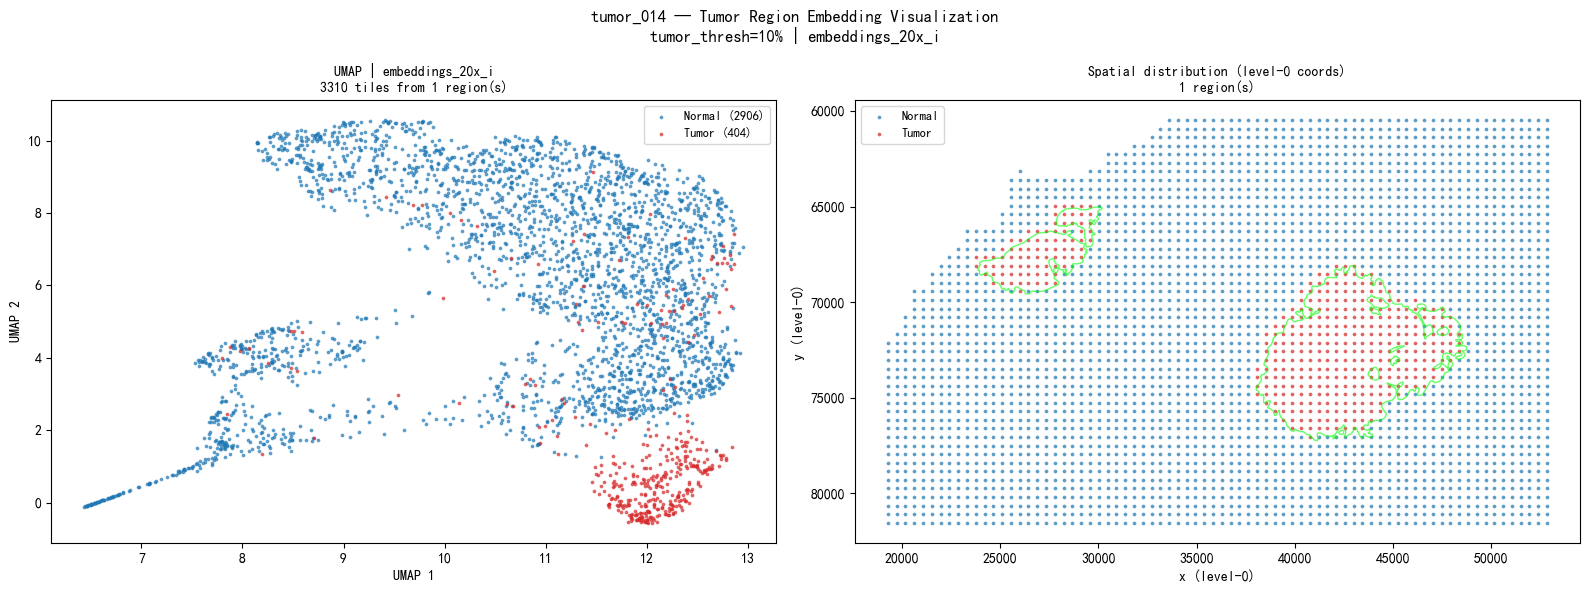

In [ ]:
def plot_embedding_by_region(tumor_labels, tissue_mask, embeddings, coords,
                             n_rows, n_cols, tumor_polygons, tile_size_l0,
                             context_pad, cluster_gap, slide_id, embedding_key):
    """Merge tissue tiles from all tumor regions and perform unified dimensionality-reduction visualization (one plot group)."""
    from shapely.geometry import box as shapely_box

    tumor_grid  = tumor_labels.reshape(n_rows, n_cols)

    regions = cluster_tumor_regions(tumor_grid, context_pad, cluster_gap)
    if not regions:
        print("No tumor regions found.")
        return

    # Merge tile indices from all regions (deduplicated)
    all_indices = set()
    for rslice, cslice in regions:
        row_idx = np.arange(rslice.start, rslice.stop)
        col_idx = np.arange(cslice.start, cslice.stop)
        mesh_r, mesh_c = np.meshgrid(row_idx, col_idx, indexing='ij')
        all_indices.update(mesh_r.ravel() * n_cols + mesh_c.ravel())

    all_indices = np.array(sorted(all_indices))

    # Keep tissue tiles only
    is_tissue = tissue_mask[all_indices]
    tissue_indices = all_indices[is_tissue]

    if len(tissue_indices) < 10:
        print(f"Too few tissue tiles across all regions ({len(tissue_indices)}), skipping.")
        return

    embs   = embeddings[tissue_indices]
    labels = tumor_labels[tissue_indices]
    cds    = coords[tissue_indices]

    # Filter out zero vectors
    nz_mask = np.abs(embs).sum(axis=1) > 0
    embs   = embs[nz_mask]
    labels = labels[nz_mask]
    cds    = cds[nz_mask]
    n_tumor_v  = int(labels.sum())
    n_normal_v = len(labels) - n_tumor_v

    if len(embs) < 10:
        print(f"Too few non-zero embeddings ({len(embs)}), skipping.")
        return

    print(f"All regions merged: {len(embs)} tiles "
          f"(tumor={n_tumor_v}, normal={n_normal_v}) from {len(regions)} region(s)")

    # Dimensionality reduction
    try:
        import umap
        print(f"  Using UMAP (N={len(embs)}) ...")
        reducer = umap.UMAP(n_components=2, n_neighbors=min(30, len(embs)-1),
                            min_dist=0.1, random_state=42)
        coords2d = reducer.fit_transform(embs)
        method = 'UMAP'
    except ImportError:
        from sklearn.manifold import TSNE
        from sklearn.decomposition import PCA
        N_emb = len(embs)
        perp = min(40, N_emb // 4)
        if N_emb > 5000:
            print(f"  PCA 50 -> t-SNE (N={N_emb}) ...")
            embs_r = PCA(n_components=50, random_state=42).fit_transform(embs)
            method = 'PCA+t-SNE'
        else:
            print(f"  t-SNE (N={N_emb}, perp={perp}) ...")
            embs_r = embs
            method = 't-SNE'
        coords2d = TSNE(n_components=2, perplexity=max(5, perp),
                        random_state=42).fit_transform(embs_r)

    # Plot one group: left = reduced-space scatter, right = spatial distribution
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    s = max(3, min(20, 10000 // len(embs)))
    axes[0].scatter(coords2d[~labels, 0], coords2d[~labels, 1],
                    c='tab:blue', s=s, alpha=0.6, label=f'Normal ({n_normal_v})')
    axes[0].scatter(coords2d[labels, 0], coords2d[labels, 1],
                    c='tab:red', s=s, alpha=0.6, label=f'Tumor ({n_tumor_v})')
    axes[0].legend(fontsize=9)
    axes[0].set_title(f"{method} | {embedding_key}\n"
                      f"{len(embs)} tiles from {len(regions)} region(s)", fontsize=10)
    axes[0].set_xlabel(f"{method} 1")
    axes[0].set_ylabel(f"{method} 2")

    # Right: spatial distribution coloring
    cols_v = cds[:, 0].astype(float)
    rows_v = cds[:, 1].astype(float)
    axes[1].scatter(cols_v[~labels], rows_v[~labels],
                    c='tab:blue', s=max(2, s), alpha=0.6, label='Normal')
    axes[1].scatter(cols_v[labels], rows_v[labels],
                    c='tab:red', s=max(2, s), alpha=0.6, label='Tumor')

    # Draw only annotation contours intersecting merged regions
    for rslice, cslice in regions:
        x_min = cslice.start * tile_size_l0
        x_max = cslice.stop * tile_size_l0
        y_min = rslice.start * tile_size_l0
        y_max = rslice.stop * tile_size_l0
        region_box = shapely_box(x_min, y_min, x_max, y_max)
        for poly in tumor_polygons:
            if poly.intersects(region_box):
                exterior = np.array(poly.exterior.coords)
                axes[1].plot(exterior[:, 0], exterior[:, 1],
                             color='lime', linewidth=1, alpha=0.6)

    axes[1].invert_yaxis()
    axes[1].legend(fontsize=9)
    axes[1].set_title(f"Spatial distribution (level-0 coords)\n"
                      f"{len(regions)} region(s)", fontsize=10)
    axes[1].set_xlabel("x (level-0)")
    axes[1].set_ylabel("y (level-0)")

    fig.suptitle(
        f"{slide_id} — Tumor Region Embedding Visualization\n"
        f"tumor_thresh={TUMOR_THRESH:.0%} | {embedding_key}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


plot_embedding_by_region(
    tumor_labels, tissue_mask, embeddings, coords,
    n_rows, n_cols, tumor_polygons, tile_size_l0,
    CONTEXT_PAD, CLUSTER_GAP, SLIDE_ID, EMBEDDING_KEY,
)


## Figure 4: Global Embedding Dimensionality Reduction (optional)

Reduce embeddings for all tissue tiles in the whole WSI, color by tumor vs normal, and inspect global distribution.

In [ ]:
# # Global tissue tiles
# tissue_idx = np.where(tissue_mask)[0]
# embs_all   = embeddings[tissue_idx]
# labels_all = tumor_labels[tissue_idx]
# cds_all    = coords[tissue_idx]

# # Filter zero vectors
# nz = np.abs(embs_all).sum(axis=1) > 0
# embs_all   = embs_all[nz]
# labels_all = labels_all[nz]
# cds_all    = cds_all[nz]

# n_tumor_all  = int(labels_all.sum())
# n_normal_all = len(labels_all) - n_tumor_all
# print(f"Global: {len(embs_all)} tissue tiles (tumor={n_tumor_all}, normal={n_normal_all})")

# # Dimensionality reduction
# try:
#     import umap
#     print(f"Using UMAP (N={len(embs_all)}) ...")
#     reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
#     g_coords2d = reducer.fit_transform(embs_all)
#     g_method = 'UMAP'
# except ImportError:
#     from sklearn.manifold import TSNE
#     from sklearn.decomposition import PCA
#     N_g = len(embs_all)
#     if N_g > 5000:
#         print(f"PCA 50 -> t-SNE (N={N_g}) ...")
#         embs_pca = PCA(n_components=50, random_state=42).fit_transform(embs_all)
#         g_method = 'PCA+t-SNE'
#     else:
#         embs_pca = embs_all
#         g_method = 't-SNE'
#     perp = min(40, N_g // 4)
#     g_coords2d = TSNE(n_components=2, perplexity=max(5, perp),
#                       random_state=42).fit_transform(embs_pca)

# print(f"Reduction done: {g_method}")

# # Plotting
# fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# s = max(1, min(8, 30000 // len(embs_all)))

# axes[0].scatter(g_coords2d[~labels_all, 0], g_coords2d[~labels_all, 1],
#                 c='tab:blue', s=s, alpha=0.4, label=f'Normal ({n_normal_all})')
# axes[0].scatter(g_coords2d[labels_all, 0], g_coords2d[labels_all, 1],
#                 c='tab:red', s=s, alpha=0.5, label=f'Tumor ({n_tumor_all})')
# axes[0].legend(fontsize=10)
# axes[0].set_title(f"{g_method} | {EMBEDDING_KEY}\n"
#                   f"all tissue tiles N={len(embs_all)}", fontsize=11)
# axes[0].set_xlabel(f"{g_method} 1")
# axes[0].set_ylabel(f"{g_method} 2")

# # Spatial distribution
# axes[1].scatter(cds_all[~labels_all, 0], cds_all[~labels_all, 1],
#                 c='tab:blue', s=max(1, s), alpha=0.3)
# axes[1].scatter(cds_all[labels_all, 0], cds_all[labels_all, 1],
#                 c='tab:red', s=max(1, s), alpha=0.5)
# for poly in tumor_polygons:
#     ext = np.array(poly.exterior.coords)
#     axes[1].plot(ext[:, 0], ext[:, 1], color='lime', linewidth=1.2, alpha=0.7)
# axes[1].invert_yaxis()
# axes[1].set_title(f"Spatial: tumor (red) vs normal (blue)", fontsize=11)
# axes[1].set_xlabel("x (level-0)")
# axes[1].set_ylabel("y (level-0)")

# fig.suptitle(
#     f"{SLIDE_ID} — Global embedding | "
#     f"tumor_thresh={TUMOR_THRESH:.0%} | {EMBEDDING_KEY}",
#     fontsize=13,
# )
# plt.tight_layout()
# plt.show()

## Summary

Modify the parameters at the top to switch WSI and configuration:

```python
SLIDE_ID      = "tumor_005"         # switch WSI
TUMOR_THRESH  = 0.10                # lower threshold: more tiles labeled as tumor
CONTEXT_PAD   = 15                  # enlarge visualization region
EMBEDDING_KEY = "embeddings_20x_i"  # switch to ImageNet embedding
```

# Inject tumor/normal label information for each tile into the H5 database

New field:
tumor_mask:  (N,) bool  # [precomputed] whether each tile is tumor (area threshold 0.1)

In [ ]:
# Batch-inject tumor_mask into H5 files for all tumor WSIs
# Uses parse_annotations_xml / compute_tile_tumor_labels defined in Cell 5
# Area threshold fixed at 0.10

INJECT_THRESH = 0.10

h5_files = sorted(H5_DIR.glob("tumor_*.h5"))
xml_files_available = {p.stem for p in ANNOT_DIR.glob("tumor_*.xml")}

print(f"H5 files: {len(h5_files)}, XML annotations: {len(xml_files_available)}")
print(f"Tumor area threshold: {INJECT_THRESH}")
print("=" * 70)

n_done = 0
n_skip_no_xml = 0
n_skip_exists = 0
n_error = 0

for h5_file in h5_files:
    slide_id = h5_file.stem
    xml_file = ANNOT_DIR / f"{slide_id}.xml"

    # Skip: no matching annotation XML
    if slide_id not in xml_files_available:
        n_skip_no_xml += 1
        print(f"[SKIP] {slide_id}: no annotation XML")
        continue

    # Skip: tumor_mask already exists
    with h5py.File(h5_file, 'r') as f:
        if 'tumor_mask' in f:
            n_skip_exists += 1
            print(f"[SKIP] {slide_id}: tumor_mask already exists")
            continue

    try:
        # 1) Parse annotation
        polygons = parse_annotations_xml(xml_file)

        # 2) Read coords
        with h5py.File(h5_file, 'r') as f:
            coords_h5 = f['coords'][:]
            tile_sz = int(f.attrs['tile_size'])

        # tile_size_l0: inferred from neighboring coordinate spacing
        xs_u = np.sort(np.unique(coords_h5[:, 0]))
        ts_l0 = int(xs_u[1] - xs_u[0]) if len(xs_u) > 1 else tile_sz

        # 3) Compute tumor ratio -> bool mask
        print(f"[PROC] {slide_id}: {len(coords_h5)} tiles, "
              f"{len(polygons)} polygons, tile_l0={ts_l0} ...")
        ratios = compute_tile_tumor_labels(coords_h5, ts_l0, polygons)
        tmask = ratios >= INJECT_THRESH
        n_t = int(tmask.sum())

        # 4) Write to H5
        with h5py.File(h5_file, 'a') as f:
            f.create_dataset('tumor_mask', data=tmask, dtype=bool,
                             compression='gzip', compression_opts=4)

        print(f"         -> tumor_mask written: {n_t}/{len(tmask)} "
              f"({n_t/len(tmask)*100:.1f}%) tumor tiles")
        n_done += 1

    except Exception as e:
        n_error += 1
        print(f"[ERROR] {slide_id}: {e}")

print("=" * 70)
print(f"Done. processed={n_done}, skip_exists={n_skip_exists}, "
      f"skip_no_xml={n_skip_no_xml}, errors={n_error}")


H5 files: 111, XML annotations: 111
Tumor area threshold: 0.1
[PROC] tumor_001: 107474 tiles, 2 polygons, tile_l0=448 ...
    bbox pre-filter: 224/107474 candidates
         -> tumor_mask written: 81/107474 (0.1%) tumor tiles
[PROC] tumor_002: 106820 tiles, 1 polygons, tile_l0=448 ...
    bbox pre-filter: 24/106820 candidates
         -> tumor_mask written: 10/106820 (0.0%) tumor tiles
[PROC] tumor_003: 107474 tiles, 14 polygons, tile_l0=448 ...
    bbox pre-filter: 289/107474 candidates
         -> tumor_mask written: 59/107474 (0.1%) tumor tiles
[PROC] tumor_004: 107256 tiles, 8 polygons, tile_l0=448 ...
    bbox pre-filter: 304/107256 candidates
         -> tumor_mask written: 201/107256 (0.2%) tumor tiles
[PROC] tumor_005: 106820 tiles, 4 polygons, tile_l0=448 ...
    bbox pre-filter: 54/106820 candidates
         -> tumor_mask written: 21/106820 (0.0%) tumor tiles
[PROC] tumor_006: 107474 tiles, 5 polygons, tile_l0=448 ...
    bbox pre-filter: 252/107474 candidates
         -> tum